## Import

In [1]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import warnings
import re
import os
import pickle
import xgboost as xgb
import xgboost
import gc
from datetime import datetime as dt
from ast import literal_eval
from collections import Counter
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import argparse
import csv
from sklearn.preprocessing import MinMaxScaler
from joblib import dump, load
import sqlalchemy as sa 
from sqlalchemy import text 
import datetime
import random
import seaborn as sns 
import matplotlib.pyplot as plt 
import polars as pl 
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from typing import List

import scipy.sparse as sp
from sklearn.feature_selection import SelectKBest, chi2
# import shap

import matplotlib.pyplot as plt
import seaborn as sns
# import plotly.express as px
# import pyodbc



In [60]:
# %%capture
!pip install pyodbc

Defaulting to user installation because normal site-packages is not writeable


## Defin Functions

In [2]:
def comma_tokenizer(text):
    return text.split(',')

def loadModel( modelPath ):
        """
        a.loadModel(modelPath)        
        Load model that dumping with pickle        
        Parameter
        ---------
        modelPath: path of model        
        """
        # myOutputPath = './models/SelectedModel/'
        # myOutputPath = modelPath + '/Outputs'
        try:
            print(modelPath)
            if  'pickle' in modelPath:
                model = pickle.load(open(modelPath, 'rb'))
                return model 
            else:
                model=XGBClassifier()
                model.load_model(modelPath)
                # model.get_booster().dump_model(os.path.join(myOutputPath ,'xgboost_model.txt'))
                # model.get_booster().dump_model(os.path.join(myOutputPath ,'xgboost_model_with_stats.txt') , with_stats=True)
                modelDF = model.get_booster().trees_to_dataframe()
                # modelDF.to_csv(os.path.join(myOutputPath, 'ModelDF.csv'), index=False)
                # modelDF.to_csv(os.path.join(myOutputPath, 'ModelDFFullPercision.csv'), index=False, float_format="%.17g")
                return model, modelDF
        
        except Exception as e :
            print('An Error Was Accurated In load model!')
            print (e)


def compute_custom_tfidf(second_file_data, vectorizerModel, allowed_trigrams_set):
    tic = dt.now()
    
    model_features = list(allowed_trigrams_set)
    n_features = len(model_features)
    n_docs = len(second_file_data)
    allowed_numbers = set()
    trigram_to_small_idx = {}
    trigram_to_idf = {}
    missing_trigrams = []
    vocab = vectorizerModel.vocabulary_
    idf_array = vectorizerModel.idf_
    
    for i, trigram in enumerate(model_features):
        # Store trigram to index mapping
        trigram_to_small_idx[trigram] = i
        
        # Extract numbers from trigram and add to allowed_numbers
        numbers = trigram.split()
        allowed_numbers.update(numbers)
        
        # Get IDF value
        orig_idx = vocab.get(trigram)
        if orig_idx is not None:
            trigram_to_idf[trigram] = idf_array[orig_idx]
        else:
            trigram_to_idf[trigram] = 1.0  # Default value
            missing_trigrams.append(trigram)
    
    # Warning only if needed
    if missing_trigrams:
        print(f"[Warning] missing {len(missing_trigrams)} trigrams")
    
    # OPTIMIZATION 2: Pre-compile docs_trigrams_filtered efficiently
    docs_trigrams_filtered = []
    trigram_in_idx = trigram_to_small_idx.__contains__  # Faster method lookup
    
    for row in second_file_data:
        # Split once and filter using set lookup
        numbers = row.split(',')
        
        # OPTIMIZATION 3: Filter numbers more efficiently
        filtered_numbers = [num for num in numbers if num in allowed_numbers]
        
        # Generate trigrams only if we have at least 3 numbers
        if len(filtered_numbers) < 3:
            docs_trigrams_filtered.append([])
            continue
            
        # OPTIMIZATION 4: Generate and filter trigrams in one pass
        valid_trigrams = []
        # Pre-calculate range end
        end_idx = len(filtered_numbers) - 2
        
        for i in range(end_idx):
            trigram = f"{filtered_numbers[i]} {filtered_numbers[i+1]} {filtered_numbers[i+2]}"
            if trigram_in_idx(trigram):
                valid_trigrams.append(trigram)
        
        docs_trigrams_filtered.append(valid_trigrams)
    
    # OPTIMIZATION 5: Initialize matrix with zeros (already good)
    tfidf_matrix = np.zeros((n_docs, n_features))
    
    # OPTIMIZATION 6: Use local variables for faster access in loop
    get_idx = trigram_to_small_idx.get
    get_idf = trigram_to_idf.get
    
    for i, trigrams in enumerate(docs_trigrams_filtered):
        if not trigrams:
            continue
            
        # OPTIMIZATION 7: Use Counter only if needed, otherwise simple dict
        if len(trigrams) > 50:  # Threshold for using Counter
            tf_counter = Counter(trigrams)
            for tg, count in tf_counter.items():
                small_idx = get_idx(tg)
                if small_idx is not None:
                    tfidf_matrix[i, small_idx] = count # np.round(count * get_idf(tg),5) deleted 
        else:
            # Manual counting for small lists (faster than Counter)
            counts = {}
            for tg in trigrams:
                counts[tg] = counts.get(tg, 0) + 1
            
            for tg, count in counts.items():
                small_idx = get_idx(tg)
                if small_idx is not None:
                    tfidf_matrix[i, small_idx] = count  # np.round(count * get_idf(tg),5)  deleted 
    
    print(f'[Custom TF-IDF] Time: {dt.now() - tic}, '
          f'Docs: {n_docs}, Features: {n_features}')
    
    return pd.DataFrame(tfidf_matrix, columns=model_features)


def loadSeq() :
    server = '172.19.101.57'
    database = 'etw'
    username = 'labDevelopers'
    password = '1qaz!QAZ'
    cnxn = pyodbc.connect('DRIVER={ODBC Driver 18 for SQL Server};SERVER='+server+';DATABASE='+database+';UID='+username+';PWD='+password+';Encrypt=no;TrustServerCertificate=yes;Connection Timeout=300')
    df = pd.read_sql_query("SELECT * FROM Providers WITH (NOLOCK)", cnxn)
    cnxn.close()
    # write(df)
    return df


def featuresSelection( dictionaryFilePath , vectorizer ):
        with open(dictionaryFilePath, "r", encoding="utf-8") as f:
            tokens = [line.strip() for line in f if line.strip()]
        grouped_tokens = [
            ' '.join(tokens[i:i+3])
            for i in range(0, len(tokens), 3)
            if len(tokens[i:i+3]) == 3
        ]
        vocab = vectorizer.vocabulary_   # token -> index
        idf = vectorizer.idf_            # index -> idf value
        grouped_idfs = []
        idfs = [idf[vocab[t]] for t in grouped_tokens]
        grouped_idfs.append(idfs)
        return grouped_tokens, grouped_idfs[0]

def read_second_file(file_name):
    if not os.path.exists(file_name):
        raise FileNotFoundError(f"File '{file_name}' not found.")
    rows = []  
    with open(file_name, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1): 
            line = line.strip()
            if not line:
                continue  
            
            parts = line.split('|')
            if len(parts) < 3:  
                print(f" Error in line :{line_num} |  with values : {line}")
                continue
            
            row = {
                'ID': line_num,
                'FileName': file_name.split('/')[-1],
                'ProcessPath': parts[2],
                'PID': int(parts[1]),
                'Label': 0,
                'SEQ': ','.join(parts[3:]),
            }
            rows.append(row)
    
    data = pd.DataFrame(rows, columns=['ID', 'FileName', 'ProcessPath', 'PID', 'Label', 'SEQ'])
    if data.empty:
        print("There is No File !!!")
    return data

    
def clean_seq_column(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        pl.col("SEQ")
        .str.split(",")                               # تبدیل رشته به لیست 
        .list.eval(                                   # پردازش داخل لیست
            pl.element().filter(pl.element() != "22") # حذف آیتم‌های "22"
        )
        .list.join(",")                               # تبدیل لیست به رشته
        .alias("SEQ")                           # ستون جدید
    )

def RandomSelect (row):
        augmentsize = 10
        row = row.split(',')
        randint = np.random.randint(0, len(row), size = augmentsize)
        return [','.join(row[ : i]) for i in randint]




## Data Load 

### original data 

In [4]:
tr_te = 'visualizing'
n_samples = 500_000
CHUNK_SIZE = 500_000

print(f"[Read] original data...  ")
tic = dt.now()
dataname = "sqldata-04-25-26.parquet"
datapath = "./DATA/"

df = pl.read_parquet(os.path.join(datapath, dataname))
df = df.with_columns((pl.col("Label") % 2).alias("Label"))

b9_count = df.filter(pl.col("Label") == 0).shape[0]
mal_count = df.filter(pl.col("Label") == 1).shape[0]
total_count = df.shape[0]
print(f'B9 : ({b9_count}, {df.width}) | Mal : ({mal_count}, {df.width}) | total : ({total_count}, {df.width})')
print('[Read] original data End \t \t \t \t \t \t \t  Time  : {}'.format(dt.now() - tic))


[Read] original data...  
B9 : (6487111, 6) | Mal : (2791276, 6) | total : (9278387, 6)
[Read] original data End 	 	 	 	 	 	 	  Time  : 0:00:03.793743


### Addition data

In [5]:
print(f"[Read] additional data...  ")
tic = dt.now()
dataname = "heurETWFeatures"
datapath = "./DATA/"
inputFilesDict = {'txt' :[],'dat':[]}
for root, folders, files in os.walk(datapath):
        for file in files:
            filePath = os.path.join(root, file)
            fileExtention = file.split('.')[-1]
            if fileExtention in inputFilesDict.keys():
                inputFilesDict[fileExtention].append(filePath)
textFilePaths = inputFilesDict.get('txt')
second_data = pd.DataFrame(columns=df.columns)
for textFilePath in textFilePaths :
        if dataname in textFilePath :
            print("Reading second file...")
            second_data_row = pd.DataFrame(read_second_file(textFilePath))
            second_data = pd.concat([second_data, second_data_row], ignore_index=True)
        else :
            print("There is No heurETWFeaturesResult")
second_data = pl.from_pandas(second_data)
print('[Read] additional data End \t \t \t \t \t \t \t  Time  : {}'.format(dt.now() - tic))


[Read] additional data...  
Reading second file...
Reading second file...
Reading second file...
Reading second file...
[Read] additional data End 	 	 	 	 	 	 	  Time  : 0:00:00.594869


In [6]:
print(f"[Concat] original data and additional data ...  ")
df = pl.concat([second_data, df], how="vertical_relaxed")
print(f"[Concat] Done ")
print(f"[clean] 22 from all SEQ.... ")
df = clean_seq_column(df)
print(f"[clean] Done ")

df.shape

[Concat] original data and additional data ...  
[Concat] Done 
[clean] 22 from all SEQ.... 
[clean] Done 


(9308687, 6)

### Augmenting 

In [8]:
print('[Augmenting]... ')
tictotalaugemnting = dt.now() ## uses in next 2 cell 
df_to_augment = df.filter(pl.col('Label') == 0) 
df_b9_with_flag = df_to_augment.with_columns(
    pl.lit(False).alias("is_augmented")
)
df_mal_with_flag = df.filter(pl.col('Label') == 1).with_columns(
    pl.lit(False).alias("is_augmented")
)

df = pl.concat([df_b9_with_flag,df_mal_with_flag ], how="vertical")
print('[Drop_duplicating] starts .... ')
tic = dt.now()
df = df.unique(subset=['SEQ'], keep='first')
print('[Drop_duplicating] Ends at \t \t \t \t \t \t \t  Time  : {}'.format(dt.now() - tic))
print(f"Number of Benign  Before Augmenting & Drop_duplicating: {len(df_b9_with_flag)} \n \t \t \t \t \t \t After: {len(df.filter(pl.col('Label') == 0))}")
print(f"Number of Malware Before Augmenting & Drop_duplicating: {len(df_mal_with_flag)}\n\t \t \t \t \t \t After: {len(df.filter(pl.col('Label') == 1))}")
print(f"Total rows after Drop_duplicating \t \t      : {len(df)}")


[Augmenting]... 
[Drop_duplicating] starts .... 
[Drop_duplicating] Ends at 	 	 	 	 	 	 	  Time  : 0:00:00.581074
Number of Benign  Before Augmenting & Drop_duplicating: 6517411 
 	 	 	 	 	 	 After: 578557
Number of Malware Before Augmenting & Drop_duplicating: 2791276
	 	 	 	 	 	 After: 262105
Total rows after Drop_duplicating 	 	      : 840662


In [9]:
print('[Augmenting 4] adding 4 if row didnt start with 4 ... ')
tic = dt.now()
df_to_augment = df.filter(pl.col('Label') == 0)

df_first = (
    df_to_augment
    .with_columns(
        pl.col("SEQ")
        .str.split(",")          # -> list of strings
        .list.get(0)             # -> first element
        .alias("first_num")
    )
)
mask_non_4 = df_first["first_num"] != "4"
augmented_rows = (
    df_to_augment.filter(mask_non_4)
    .with_columns(
        (
            pl.lit("4,") + pl.col("SEQ")
        ).alias("SEQ"),
            pl.lit(True).alias("is_augmented")
    )
)

df = pl.concat([augmented_rows,df ], how="vertical")
print(f"Before Augmenting start 4: {len(df_to_augment)}")
print(f"After  Augmenting start 4: {len(df.filter(pl.col('Label') == 0))}")
print(f"After  Augmenting start 4: {len(augmented_rows)} rows added ")
print('[Augmenting 4]  Ends at  \t \t \t \t \t Time  : {}'.format(dt.now() - tic))


[Augmenting 4] adding 4 if row didnt start with 4 ... 
Before Augmenting start 4: 578557
After  Augmenting start 4: 581363
After  Augmenting start 4: 2806 rows added 
[Augmenting 4]  Ends at  	 	 	 	 	 Time  : 0:00:02.116368


In [10]:
print('[Augmenting 10x] start ... ')
tic = dt.now()
df_to_augment = df.filter(pl.col('Label') == 0)
df_batch = df_to_augment.sample(n=n_samples, shuffle=True)
print(f" {n_samples} rows selected to augmenting by 10x rules ")

augmented_data = df_batch.select(
    pl.col('*'),
    pl.col('SEQ').map_elements(RandomSelect).alias('augmented_seq')
).explode('augmented_seq').with_columns( 
    pl.when(pl.col('SEQ') != pl.col('augmented_seq'))
    .then(pl.lit(-1))
    .otherwise(pl.col('ID'))
    .alias('ID')
).drop('augmented_seq')
Augdf = pl.concat([augmented_data,df], how='vertical')
print('[Augmenting 10x] Ends at \t \t \t \t \t \t \t  Time  : {}'.format(dt.now() - tic))
print(f"Number of Benign Befor Augmenting 10x: {len(df_to_augment)} \n \t \t \t \t \t \t After: {len(Augdf.filter(pl.col('Label') == 0))}")

print('[Drop_duplicating] starts .... ')
tic = dt.now()
Augdf = Augdf.unique(subset=['SEQ'], keep='first')
print(f"Number of Benign : {len(Augdf.filter(pl.col('Label') == 0))}")
print(f"Number of Malware: {len(Augdf.filter(pl.col('Label') == 1))}")
print(f"Total rows       : {len(Augdf)}")
print('[Drop_duplicating] Ends at \t \t \t \t \t \t \t  Time  : {}'.format(dt.now() - tic))
print('[Full Augmenting B9] Ends at \t \t \t \t \t \t \t  Time  : {}'.format(dt.now() - tictotalaugemnting))



[Augmenting 10x] start ... 
 500000 rows selected to augmenting by 10x rules 


sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


[Augmenting 10x] Ends at 	 	 	 	 	 	 	  Time  : 0:00:24.016912
Number of Benign Befor Augmenting 10x: 581363 
 	 	 	 	 	 	 After: 5581363
[Drop_duplicating] starts .... 
Number of Benign : 581070
Number of Malware: 262105
Total rows       : 843175
[Drop_duplicating] Ends at 	 	 	 	 	 	 	  Time  : 0:00:00.327274
[Full Augmenting B9] Ends at 	 	 	 	 	 	 	  Time  : 0:00:33.606642


### PreProcess 

In [11]:
print('[Removing] Malwares with       len < 7 ... ')
tic = dt.now()
df = df.with_columns([pl.col("SEQ").str.split(",").list.len().alias("seqlen")])
print(f'Malware shape Before removing  len < 7               : {df.filter(pl.col("Label").cast(pl.Int64) == 1).shape} ')
df = df.filter((pl.col("seqlen") >= 7) | (pl.col("Label").cast(pl.Int64) != 1))
print(f'Malware shape after removing   len < 7               : {df.filter(pl.col("Label").cast(pl.Int64) == 1).shape} ')
print(f'Benign with                    len < 7               : {df.filter((pl.col("seqlen") <= 7) & (pl.col("Label").cast(pl.Int64) == 0)).shape}')

print('[Removing] \t \t \t \t \t \t \t  Time  : {}'.format(dt.now() - tic))


[Removing] Malwares with       len < 7 ... 
Malware shape Before removing  len < 7               : (262105, 8) 
Malware shape after removing   len < 7               : (262095, 8) 
Benign with                    len < 7               : (808, 8)
[Removing] 	 	 	 	 	 	 	  Time  : 0:00:03.036938


In [19]:
print('[Drop_duplicating] starts .... ')
tic = dt.now()
Augdf = df.unique(subset=['SEQ'], keep='first')
print(f"Number of Benign                       : {len(Augdf.filter(pl.col('Label') == 0))}")
print(f"Number of Malware                      : {len(Augdf.filter(pl.col('Label') == 1))}")
print(f"Total rows after Drop_duplicating      : {len(Augdf)}")
print('[Drop_duplicating] Ends at \t \t \t \t \t \t \t  Time  : {}'.format(dt.now() - tic))
pAugdf =Augdf.to_pandas()


[Drop_duplicating] starts .... 
Number of Benign                       : 581070
Number of Malware                      : 262095
Total rows after Drop_duplicating      : 843165
[Drop_duplicating] Ends at 	 	 	 	 	 	 	  Time  : 0:00:00.088247


## Visualize data's 

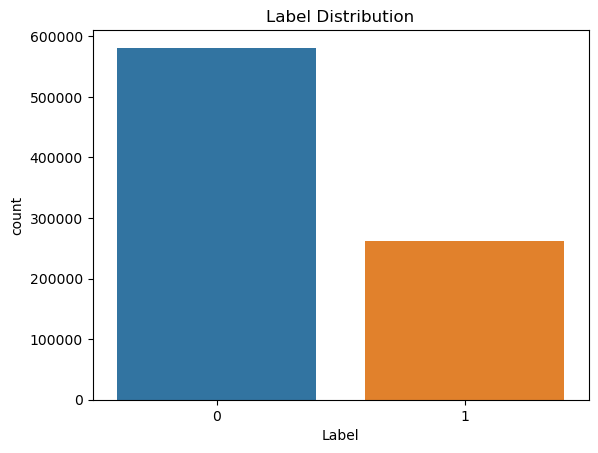

In [20]:

sns.countplot(data=pAugdf, x="Label")
plt.title("Label Distribution")
plt.show()


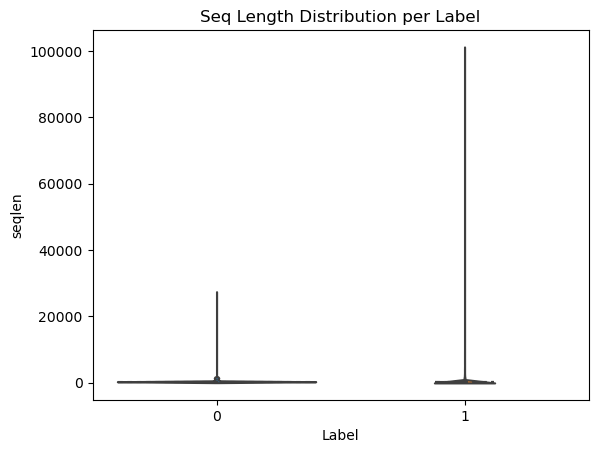

In [21]:
sns.violinplot(data=pAugdf, x="Label", y="seqlen", inner="quartile")
plt.title("Seq Length Distribution per Label")
plt.show()


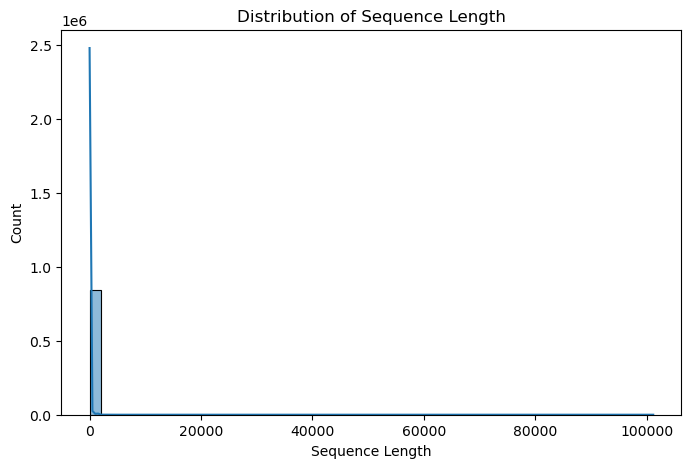

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(pAugdf['seqlen'], bins=50, kde=True)
plt.title('Distribution of Sequence Length')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.show()

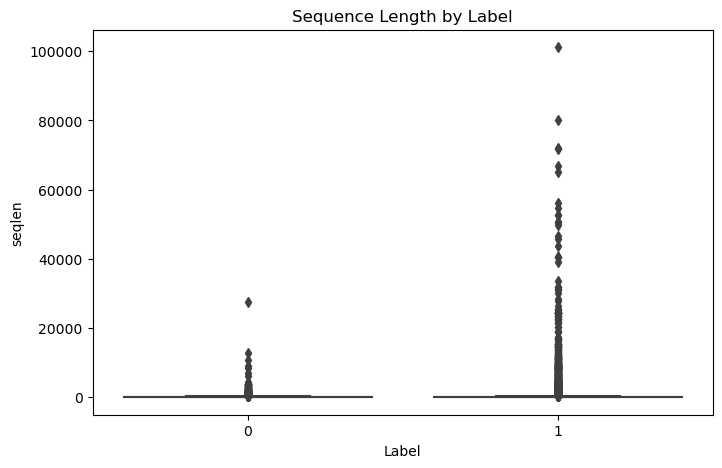

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Label', y='seqlen', data=pAugdf)
plt.title('Sequence Length by Label')
plt.show()

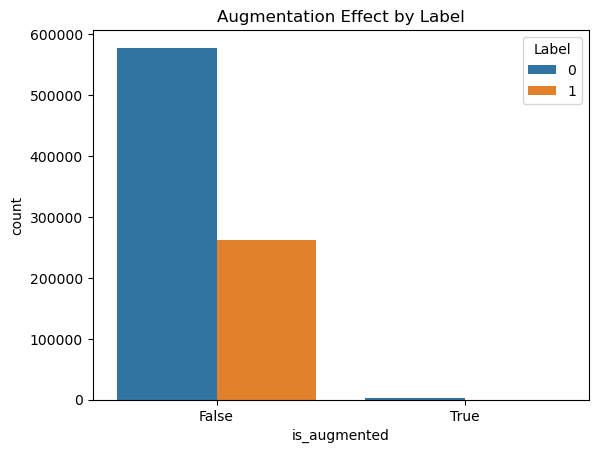

In [24]:
sns.countplot(x='is_augmented', hue='Label', data=pAugdf)
plt.title('Augmentation Effect by Label')
plt.show()

In [25]:
pAugdf['tokens'] = pAugdf['SEQ'].str.split(',')
# explode
df_exploded = (
    pAugdf
    .assign(tokens=pAugdf['SEQ'].str.split(','))
    .explode('tokens')
    .query("tokens != ''")
)

df_exploded['tokens'] = df_exploded['tokens'].astype(int)
df_exploded

,ID,FileName,ProcessPath,PID,Label,SEQ,is_augmented,seqlen,tokens
0,926892,73d66f61-sample_2025_10_24_2Ylm.txt,python.exe,7452,1,"4,4,4,4,3,4,3,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...",False,200,4
0,926892,73d66f61-sample_2025_10_24_2Ylm.txt,python.exe,7452,1,"4,4,4,4,3,4,3,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...",False,200,4
0,926892,73d66f61-sample_2025_10_24_2Ylm.txt,python.exe,7452,1,"4,4,4,4,3,4,3,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...",False,200,4
0,926892,73d66f61-sample_2025_10_24_2Ylm.txt,python.exe,7452,1,"4,4,4,4,3,4,3,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...",False,200,4
0,926892,73d66f61-sample_2025_10_24_2Ylm.txt,python.exe,7452,1,"4,4,4,4,3,4,3,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...",False,200,3
...,...,...,...,...,...,...,...,...,...
843164,5789095,2026_01_10_AI-DOWNLOADSERV_JW03WeCO_13_.txt.zip,C:\\Program Files\\Google\\Chrome\\Application...,12408,0,"4,4,4,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...",False,93,15
843164,5789095,2026_01_10_AI-DOWNLOADSERV_JW03WeCO_13_.txt.zip,C:\\Program Files\\Google\\Chrome\\Application...,12408,0,"4,4,4,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...",False,93,15
843164,5789095,2026_01_10_AI-DOWNLOADSERV_JW03WeCO_13_.txt.zip,C:\\Program Files\\Google\\Chrome\\Application...,12408,0,"4,4,4,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...",False,93,15
843164,5789095,2026_01_10_AI-DOWNLOADSERV_JW03WeCO_13_.txt.zip,C:\\Program Files\\Google\\Chrome\\Application...,12408,0,"4,4,4,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...",False,93,15


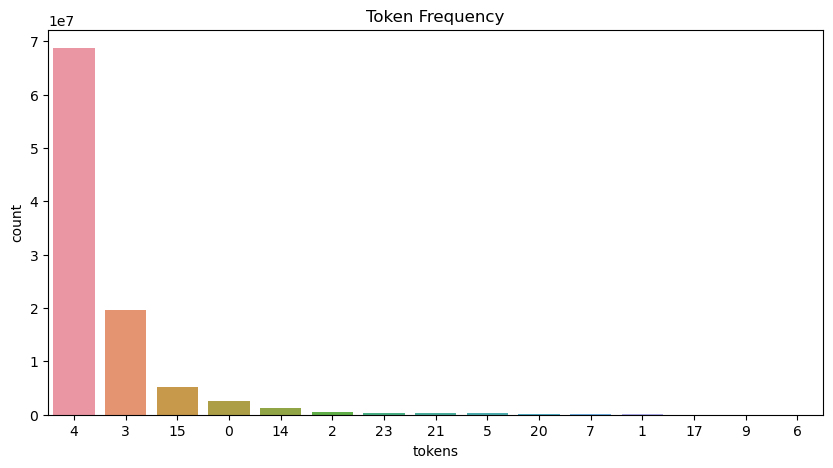

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x='tokens', data=df_exploded, order=df_exploded['tokens'].value_counts().index)
plt.title('Token Frequency')
plt.show()

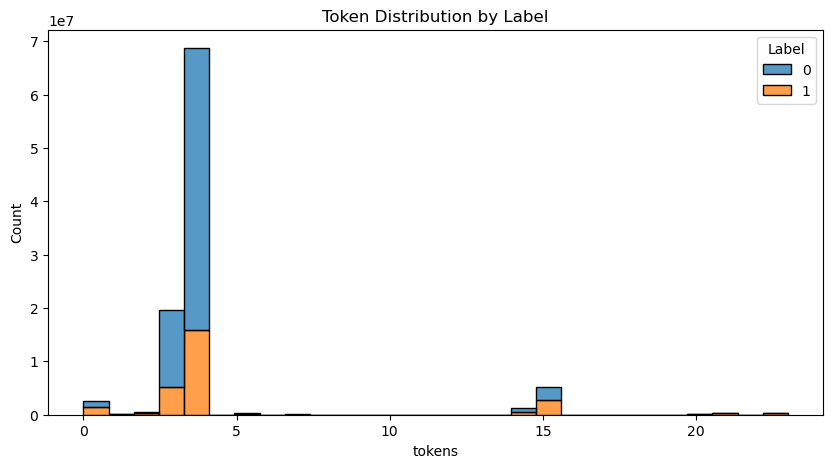

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_exploded, x='tokens', hue='Label', multiple='stack')
plt.title('Token Distribution by Label')
plt.show()

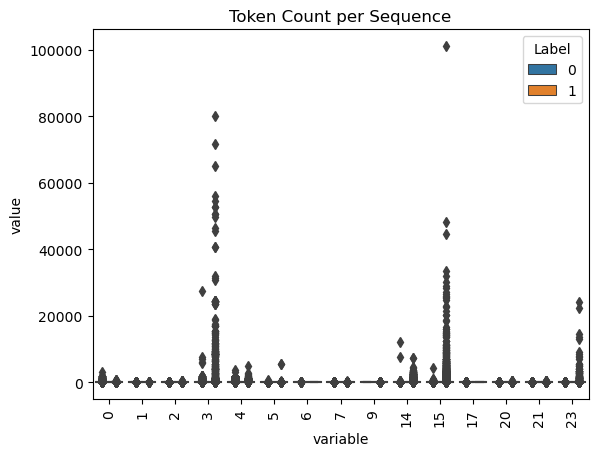

In [28]:
pAugdf['tokens'] = pAugdf['SEQ'].str.split(',').apply(
    lambda x: [int(i) for i in x if i != '']
)

token_counts = pAugdf['tokens'].apply(
    lambda x: {i: x.count(i) for i in set(x)}
)

token_df = pd.json_normalize(token_counts).fillna(0)
token_df['Label'] = pAugdf['Label'].values
token_df_melted = token_df.melt(id_vars='Label')
# sns.boxplot(data=token_df, x='variable', y='value', hue='Label')
sns.boxplot(data=token_df_melted, x='variable', y='value', hue='Label')
plt.xticks(rotation=90)
plt.title('Token Count per Sequence')
plt.show()

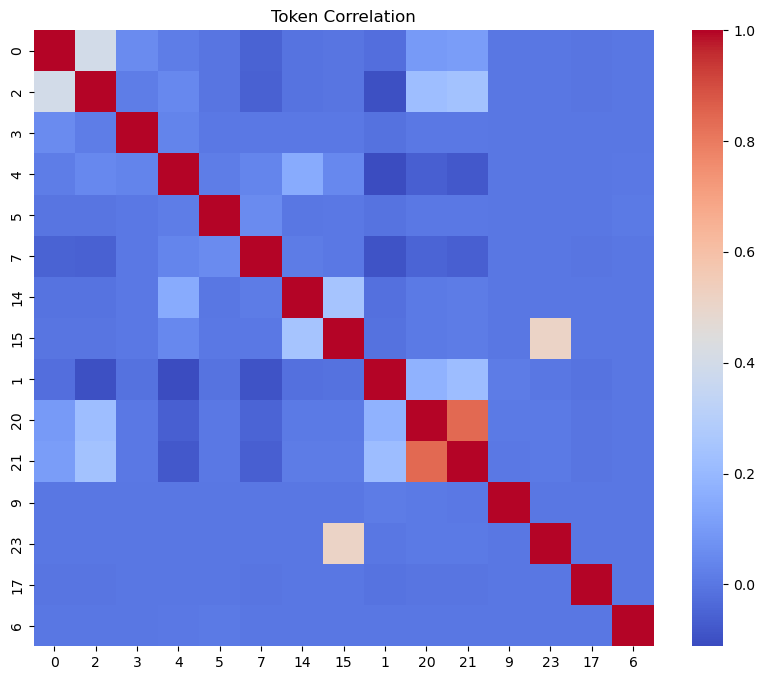

In [29]:
corr = token_df.drop(columns=['Label']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Token Correlation')
plt.show()

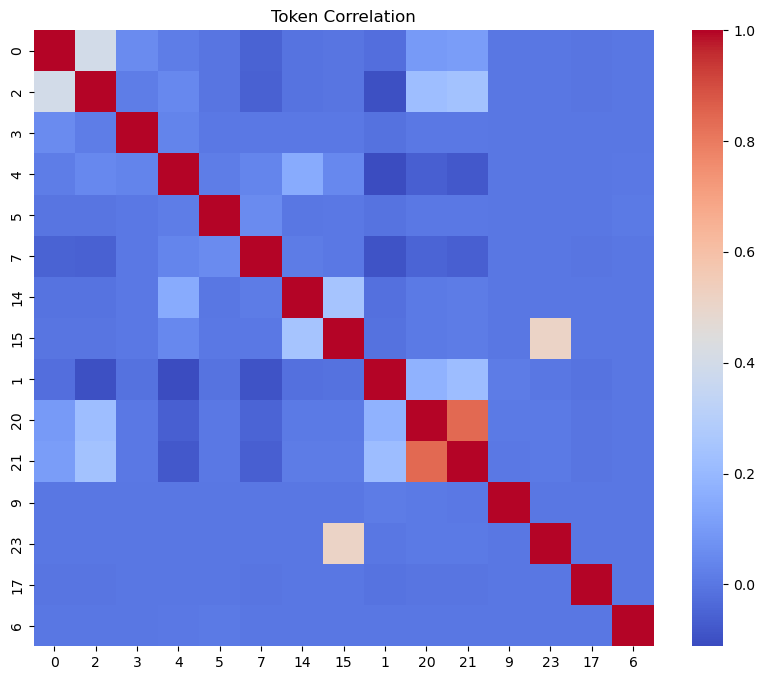

In [30]:
corr = token_df.drop(columns=['Label']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Token Correlation')
plt.show()

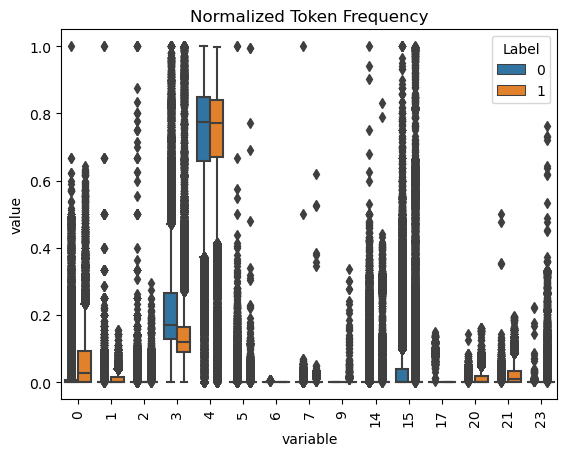

In [31]:
token_df_norm = token_df.drop(columns='Label')
token_df_norm = token_df_norm.div(token_df_norm.sum(axis=1), axis=0)

token_df_norm['Label'] = token_df['Label']

token_df_melted = token_df_norm.melt(id_vars='Label')

sns.boxplot(data=token_df_melted, x='variable', y='value', hue='Label')
plt.xticks(rotation=90)
plt.title('Normalized Token Frequency')
plt.show()

## Load Models 

In [44]:
print('Loading models...')
model_dir_path = "/home/DynamicETW//git/Train/models/SelectedModel/"
inputFilesDict = {'txt' :[],'dat':[],'name':[]}

for root, folders, files in os.walk(model_dir_path):
        for file in files:
            filePath = os.path.join(root, file)
            fileExtention = file.split('.')[-1]
            if fileExtention in inputFilesDict.keys():
                inputFilesDict[fileExtention].append(filePath)

modelFilesPath = inputFilesDict.get('dat')
vectorizerModel = None
ClassifierModel = None
for modelPath in modelFilesPath:
        if 'vectorizer' in modelPath:
            print('Loading the vectorizer model...')
            vectorizerModel =  loadModel(modelPath)
            print('This vectorizer model loaded ==>\t' + modelPath)

for modelPath in modelFilesPath:
        if 'classifier' in modelPath:
            print('Loading the classifier model...')
            ClassifierModel, _ = loadModel(modelPath)
            print('This classifier model loaded ==> ' + modelPath)

        else:
            print('Vectorizer Not Founded !')


nameFilesPath = inputFilesDict.get('name')
vocab = None
idf_values = None
for root, folders, files in os.walk(model_dir_path):
        for file in files:
            filePath = os.path.join(root, file)
            fileExtention = file.split('.')[-1]
            if fileExtention in inputFilesDict.keys():
                inputFilesDict[fileExtention].append(filePath)
                
for namePath in nameFilesPath:
        if 'dictionary' in namePath:
            print('Loading the dictionary...')
            dictionaryFilePath = namePath
            vocab , idf_values = featuresSelection (dictionaryFilePath,vectorizerModel)
            print('This dictionary loaded ==>\t' + namePath)
        else:
            print('bad naming in the name files!')


Loading models...
Loading the vectorizer model...
/home/DynamicETW//git/Train/models/SelectedModel/tfidf_vectorizer.pickle.dat
This vectorizer model loaded ==>	/home/DynamicETW//git/Train/models/SelectedModel/tfidf_vectorizer.pickle.dat
Vectorizer Not Founded !
Loading the classifier model...
/home/DynamicETW//git/Train/models/SelectedModel/classifier_detector.save_model.dat
This classifier model loaded ==> /home/DynamicETW//git/Train/models/SelectedModel/classifier_detector.save_model.dat
Loading the dictionary...
This dictionary loaded ==>	/home/DynamicETW//git/Train/models/SelectedModel/dictionary.name
bad naming in the name files!
Loading the dictionary...
This dictionary loaded ==>	/home/DynamicETW//git/Train/models/SelectedModel/dictionary.name
bad naming in the name files!


### Feature Select 

In [48]:
ClassifierModel

XGBClassifier(base_score='1.20751515E-1', booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [52]:
# exists_features = [
#     name for name in ClassifierModel.feature_names_in_
# ]
# vectorizerModel_columns = vectorizerModel.vocabulary_  
filtered_columns = vocab  # [col for col in vocab if col in exists_features]
# bow_filtered = BOW[filtered_columns]
print(f"len vectorizerModel_columns : {len(vocab)} ")
print(f"len filtered_columns : {len(filtered_columns)} ")
print("columns :")
print(filtered_columns)
print(f'[Feature Selection] Ends at \t \t \t \t Time : {dt.now() - tic}')


len vectorizerModel_columns : 107 
len filtered_columns : 107 
columns :
['0 0 0', '0 0 1', '0 0 2', '0 0 3', '0 0 4', '0 2 4', '0 21 20', '0 3 0', '0 3 1', '0 3 2', '0 3 21', '0 3 3', '0 3 4', '0 4 1', '0 4 3', '0 4 4', '1 0 0', '1 4 4', '14 15 15', '14 4 15', '14 4 3', '15 14 15', '15 15 14', '15 15 15', '15 15 3', '15 15 4', '15 3 15', '15 4 15', '15 4 3', '15 4 4', '2 0 0', '2 0 3', '2 2 0', '2 4 0', '2 4 4', '20 4 0', '20 4 1', '21 20 21', '21 20 4', '21 4 0', '21 4 4', '23 4 4', '3 0 0', '3 0 1', '3 0 2', '3 0 21', '3 0 3', '3 0 4', '3 1 4', '3 15 15', '3 2 0', '3 2 2', '3 2 4', '3 21 0', '3 21 20', '3 21 3', '3 23 4', '3 3 0', '3 3 1', '3 3 15', '3 3 21', '3 3 3', '3 3 4', '3 3 5', '3 4 0', '3 4 1', '3 4 21', '3 4 3', '3 4 4', '3 4 5', '4 0 0', '4 0 1', '4 0 3', '4 0 4', '4 1 0', '4 1 4', '4 14 15', '4 14 4', '4 15 14', '4 15 4', '4 2 2', '4 21 20', '4 3 0', '4 3 1', '4 3 15', '4 3 2', '4 3 21', '4 3 23', '4 3 3', '4 3 4', '4 4 0', '4 4 1', '4 4 14', '4 4 15', '4 4 2', '4 4 21',

### Fitting 

In [53]:
print('[Fitting Vectorizer 2] starts ... ')
BOW2 = compute_custom_tfidf(Augdf['SEQ'],vectorizerModel,np.array(pd.DataFrame(filtered_columns)[0]))
print('[Fitting Vectorizer 2] Ends at \t \t \t \t Time : {}'.format(dt.now() - tic))


[Fitting Vectorizer 2] starts ... 
[Custom TF-IDF] Time: 0:01:14.363897, Docs: 843165, Features: 107
[Fitting Vectorizer 2] Ends at 	 	 	 	 Time : 0:12:00.018218


In [55]:
print(BOW2.head)
print(BOW2.shape)

<bound method NDFrame.head of         0 0 0  0 0 1  0 0 2  0 0 3  0 0 4  0 2 4  0 21 20  0 3 0  0 3 1  \
0        16.0    0.0    0.0   17.0    0.0    0.0      0.0    5.0    0.0   
1         0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    0.0   
2         0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    0.0   
3         0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    0.0   
4         0.0    0.0    0.0    0.0    0.0    0.0      0.0    1.0    0.0   
...       ...    ...    ...    ...    ...    ...      ...    ...    ...   
843160    0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    0.0   
843161    0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    0.0   
843162    0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    0.0   
843163    0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    0.0   
843164    0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    0.0   

        0 3 2  ...  4 4 3  4 4 4  4 4 5  4 5 1  4 5 3  4 5 4  4 5 5  

### Tabel load 

In [61]:
provider_table = loadSeq()
provider_table

NameError: name 'pyodbc' is not defined

### BOW Vizulaization 

In [62]:
sparsity = (BOW2 == 0).sum().sum() / (BOW2.shape[0]*BOW2.shape[1])
print("Sparsity:", sparsity)


Sparsity: 0.8792208662388061


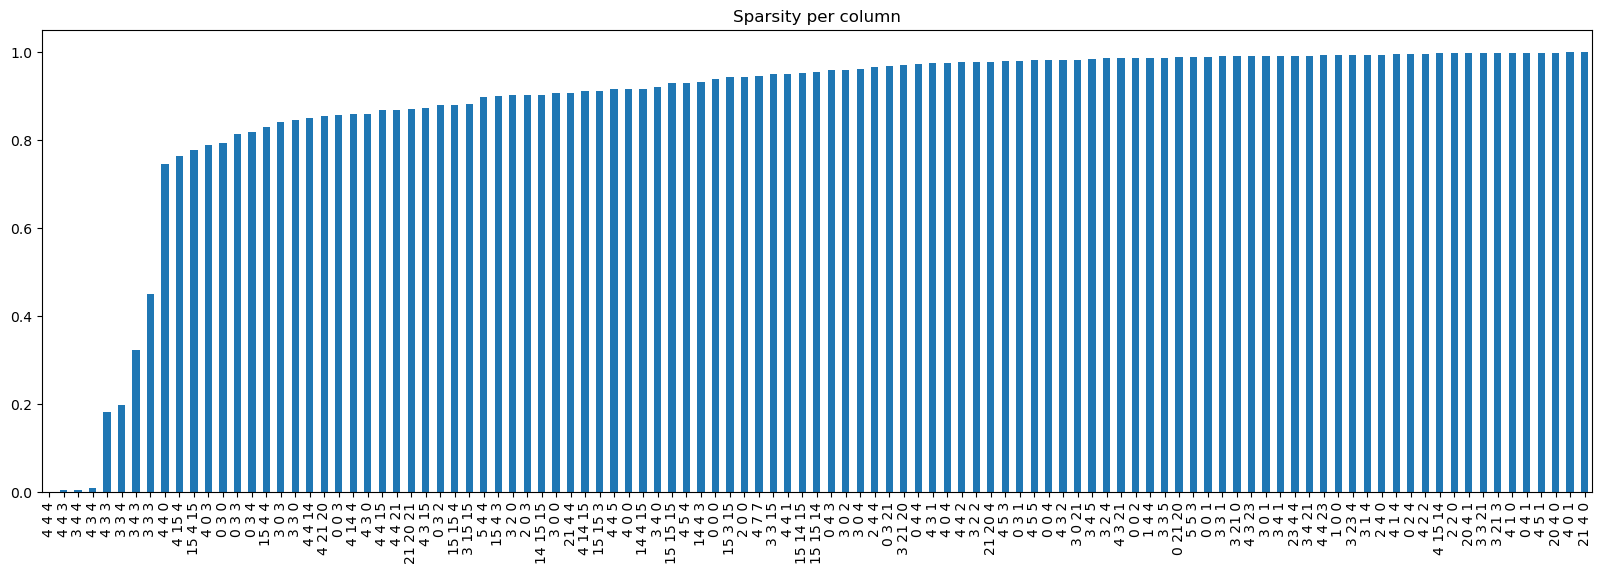

In [63]:
col_sparsity = (BOW2 == 0).sum() / BOW2.shape[0]
col_sparsity.sort_values().plot(kind="bar", figsize=(20,6))
plt.title("Sparsity per column")
plt.show()


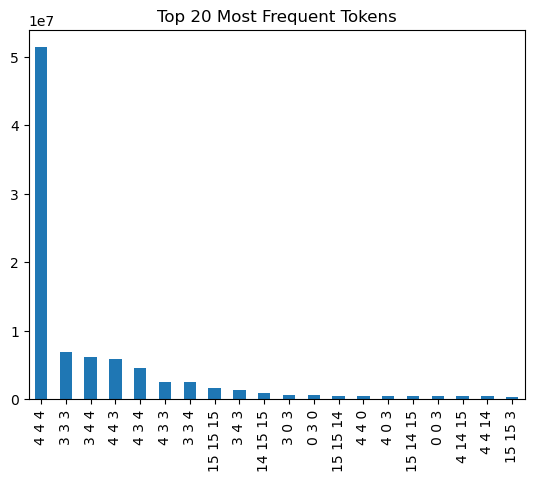

In [64]:
token_counts = BOW2.sum().sort_values(ascending=False)
token_counts.head(20).plot(kind='bar')
plt.title("Top 20 Most Frequent Tokens")
plt.show()


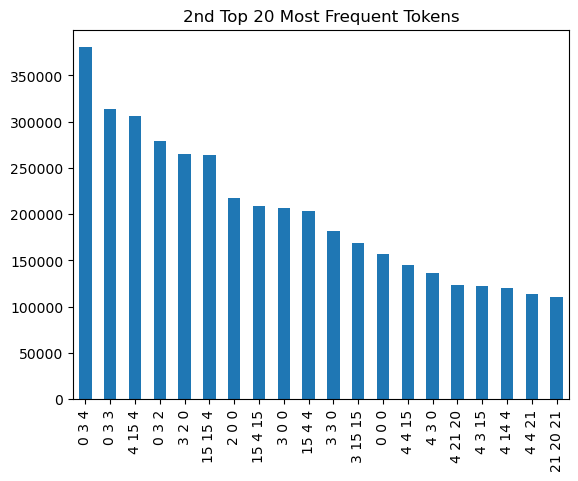

In [68]:
token_counts = BOW2.sum().sort_values(ascending=False)
token_counts[20:40].plot(kind='bar')
plt.title("2nd Top 20 Most Frequent Tokens")
plt.show()


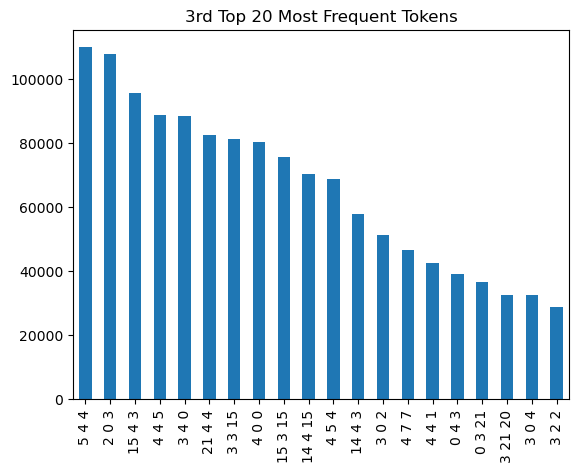

In [69]:
token_counts = BOW2.sum().sort_values(ascending=False)
token_counts[40:60].plot(kind='bar')
plt.title("3rd Top 20 Most Frequent Tokens")
plt.show()


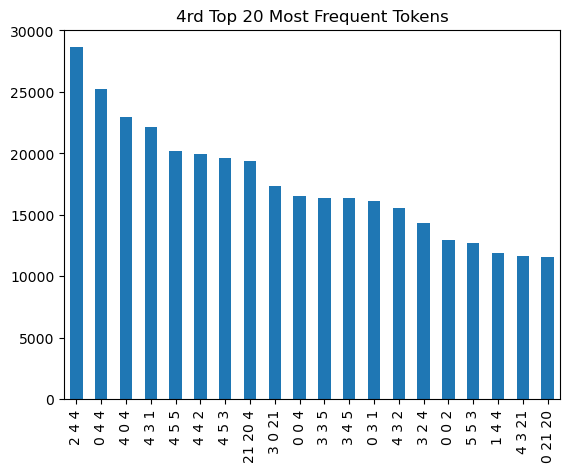

In [70]:
token_counts = BOW2.sum().sort_values(ascending=False)
token_counts[60:80].plot(kind='bar')
plt.title("4rd Top 20 Most Frequent Tokens")
plt.show()


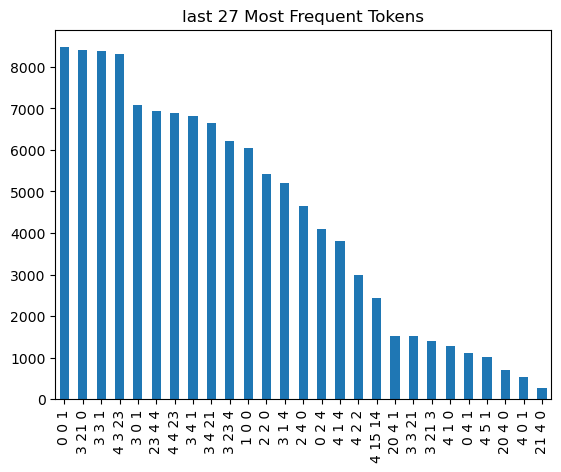

In [71]:
token_counts = BOW2.sum().sort_values(ascending=False)
token_counts[80:].plot(kind='bar')
plt.title("last 27 Most Frequent Tokens")
plt.show()


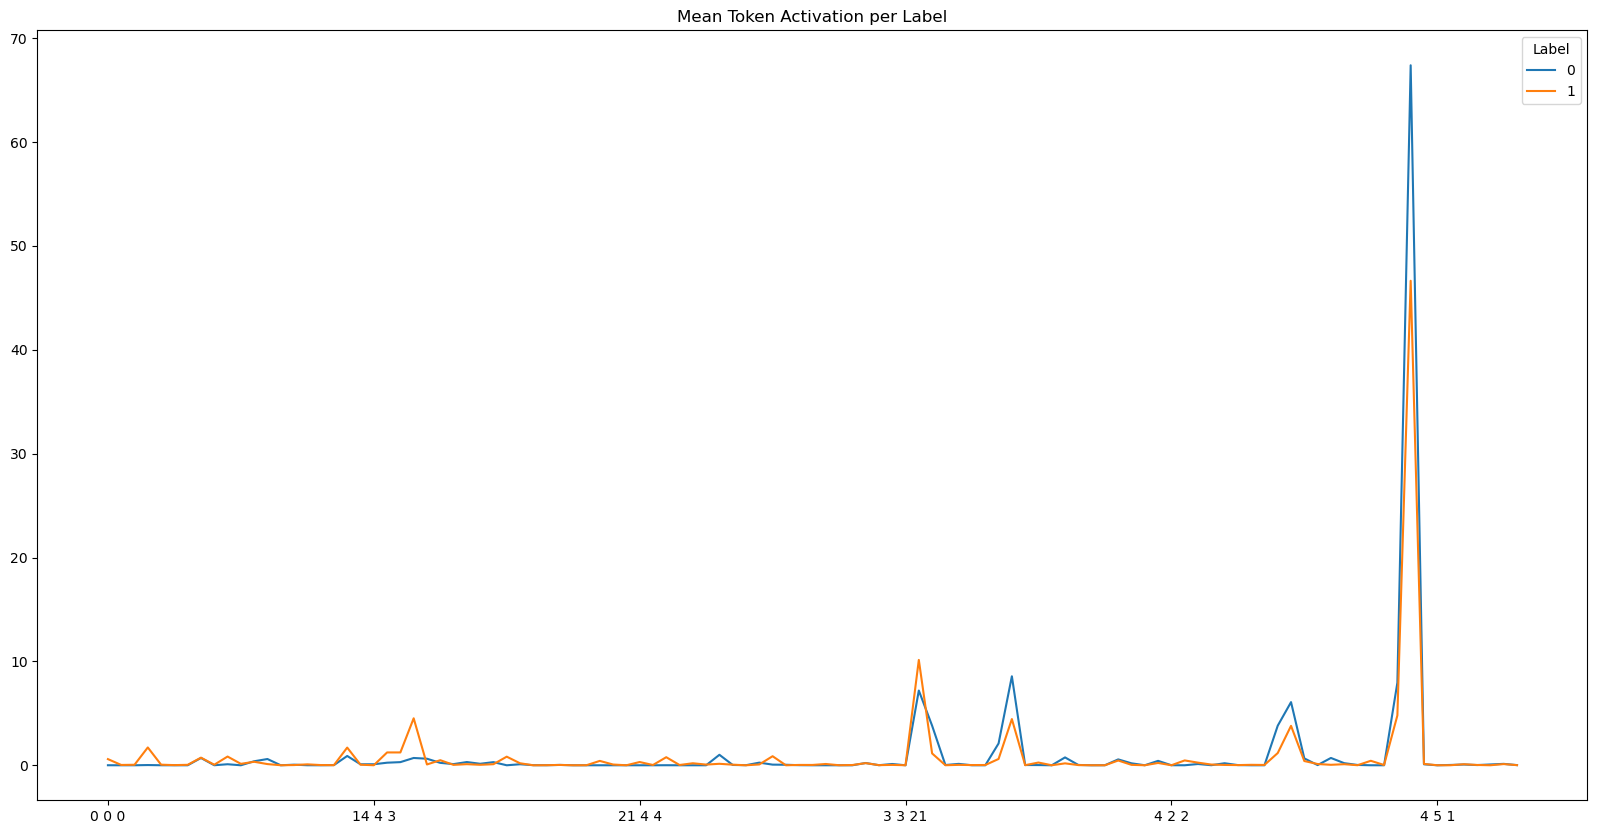

In [72]:
df_merged = pd.concat([Augdf["Label"].to_pandas(), BOW2], axis=1)
mean_per_label = df_merged.groupby("Label").mean()

mean_per_label.T.plot(figsize=(20,10))
plt.title("Mean Token Activation per Label")
plt.show()


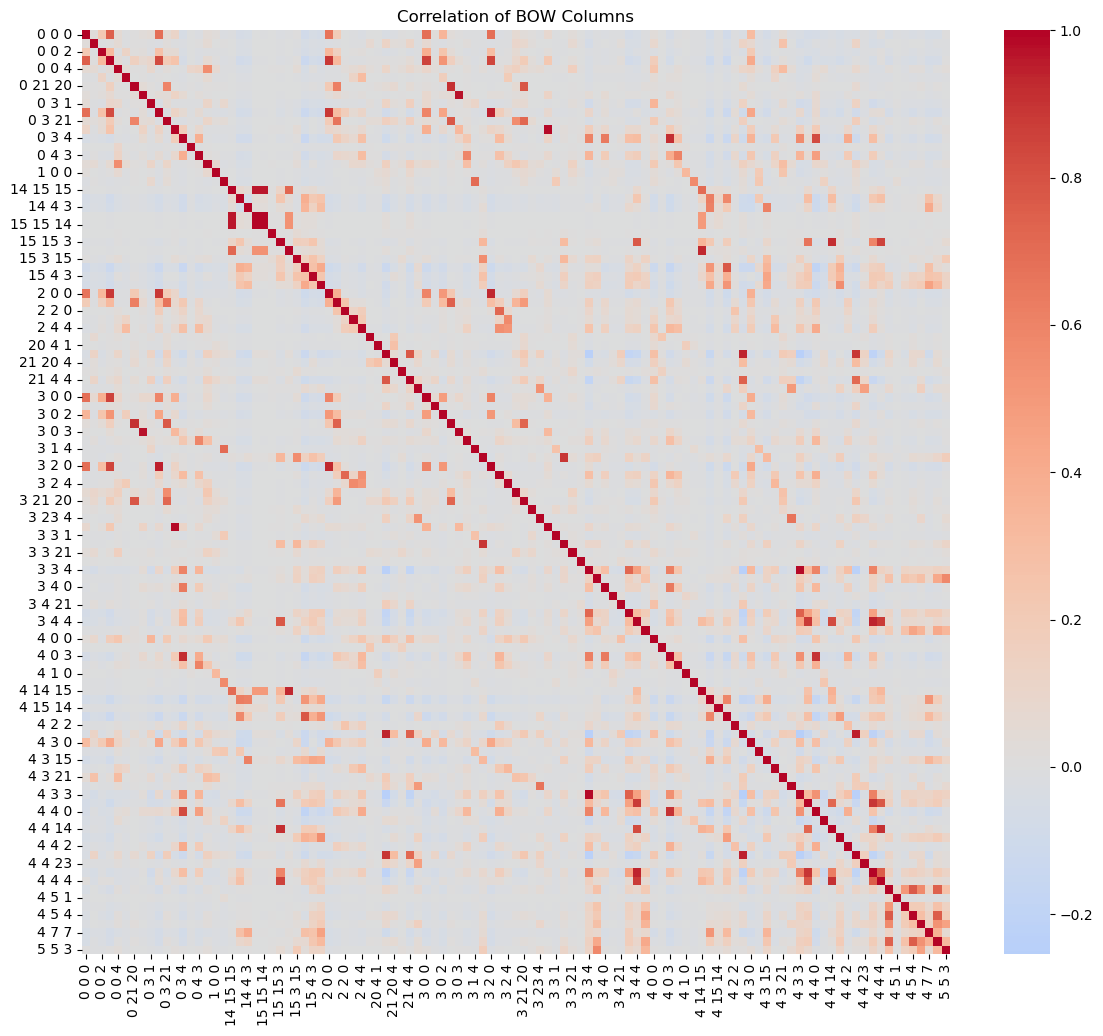

In [73]:
corr = BOW2.sample(500_000).corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation of BOW Columns")
plt.show()


In [75]:
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

sample_idx = np.random.choice(BOW2.index, 120_000, replace=False)
bow_sample = BOW2.loc[sample_idx]
label_sample = Augdf.to_pandas().loc[sample_idx, "Label"]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(bow_sample)

fig = px.scatter(x=X_pca[:,0], y=X_pca[:,1], color=label_sample.astype(str))
fig.update_layout(title="PCA of Bag-of-Words")
fig.show()
